In [1]:
import math
from sklearn.datasets import load_iris, load_wine
import matplotlib.pyplot as plt
plt.style.use("default")

### Entropy & Cost Function

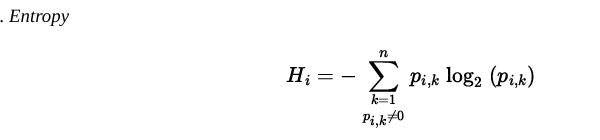
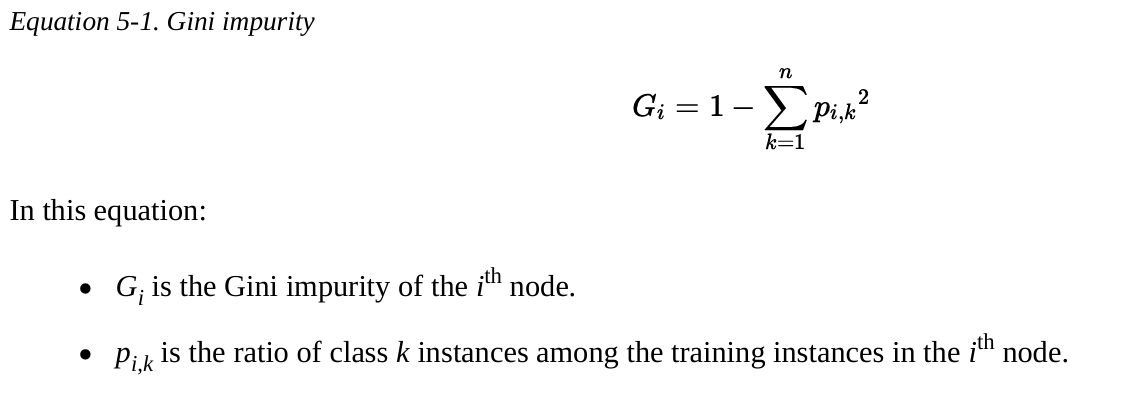

In [2]:
def Impurity(values):
    G = 0
    s = sum(values)
    if s == 0:
        return 1
    for val in values:
        if val and s:
            G -= (val/s) * math.log2(val/s)
    return G

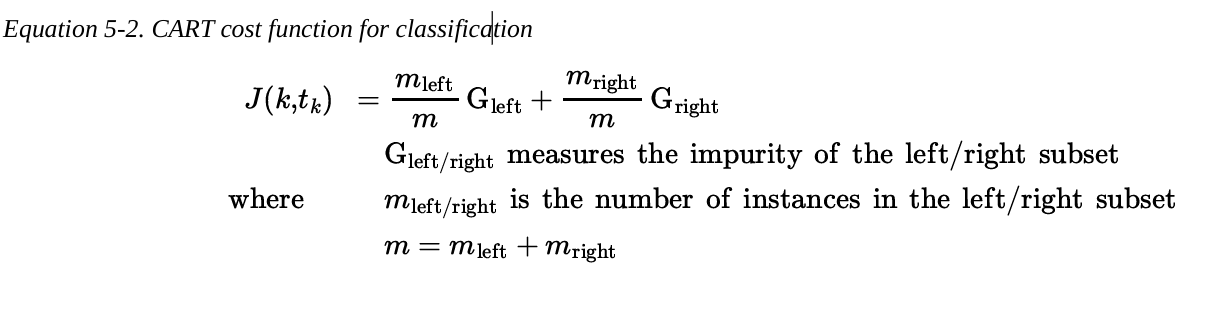
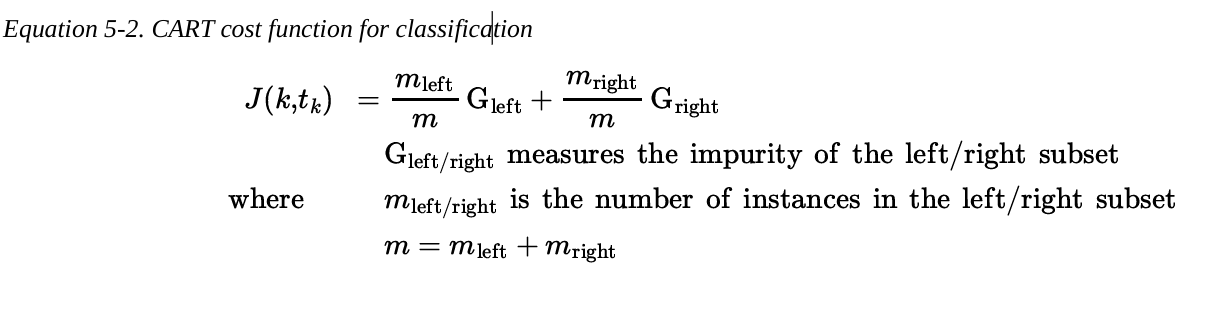

In [3]:
def Split(entropies, n, N): # CART Cost Function
    g = 0
    for entropy, n_ in zip(entropies, n):
        g += entropy*n_/N
    return g

### Decision Tree

In [4]:
def split(X, Y):
    min_entropysplit = None
    thresh_group = {}
    best_entropyl = None
    best_entropyr = None
    best_n_left = None
    best_n_right = None
    best_values_l = None
    best_values_r = None
    best_class_l = None
    best_class_r = None
    for x_range in range(int(min(X)), int(max(X) * 100) + 1):
        values_l = {i:0 for i in list(set(Y))}
        values_r = {i:0 for i in list(set(Y))}
        #print(values_l, values_r)
        for x, y in zip(X, Y):
            if x <= x_range/100:
                values_l[y] += 1
            else:
                values_r[y] += 1
        entropyl = Impurity(list(values_l.values()))
        entropyr = Impurity(list(values_r.values()))
        n_left = sum(values_l.values())
        n_right = sum(values_r.values())
        entropysplit = Split([entropyl, entropyr],[n_left, n_right], len(X))
        if min_entropysplit is None or entropysplit <= min_entropysplit:
            min_entropysplit = entropysplit
            thresh = x_range/100
            if min_entropysplit in thresh_group:
                thresh_group[min_entropysplit].append(thresh)
            else:
                thresh_group[min_entropysplit] = [thresh]
                best_entropyl = entropyl
                best_entropyr = entropyr
                best_n_left = n_left
                best_n_right = n_right
                best_values_l = list(values_l.values())
                best_values_r = list(values_r.values())
                best_class_l = int(max(values_l, key=values_l.get))
                best_class_r = int(max(values_r, key=values_r.get))

    threshold = sum(thresh_group[min_entropysplit])/ len(thresh_group[min_entropysplit])
    return threshold, min_entropysplit, {"Left": {"entropy": best_entropyl, "samples": best_n_left, "values": best_values_l, "class": best_class_l, "confidence": max(best_values_l)/sum(best_values_l)},
                       "Right": {"entropy": best_entropyr, "samples": best_n_right, "values": best_values_r, "class": best_class_r,
                                 "confidence": max(best_values_r)/sum(best_values_r)}}

In [5]:
def DT(X_data, y_data, k, entropy=None, depth=2):
    if entropy == 0:
        return
    if not depth: return
    if not k:
        return
    mini_entropy = None
    selected_k = None
    splits = None
    tk = None
    for feature in k:
        x_data = X_data[:, feature]
        tk_, entropy_, splits_ = split(x_data, y_data)
        if mini_entropy is None or mini_entropy > entropy_:
            mini_entropy = entropy_
            selected_k = feature
            tk = tk_
            splits = splits_
    left_split, right_split = splits["Left"], splits["Right"]
    print("Threshold : ", tk, "Entropy :", mini_entropy, "Feature :", selected_k)
    print("Left Split : ", left_split)
    print("Right SPlit : ", right_split)
    print()
    X_left_split_data = X_data[X_data[:, selected_k] <= tk]
    X_right_split_data = X_data[X_data[:, selected_k] > tk]
    y_left_split_data = y_data[X_data[:, selected_k] <= tk]
    y_right_split_data = y_data[X_data[:, selected_k] > tk]
    DT(X_left_split_data, y_left_split_data, k, left_split["entropy"], depth-1)
    DT(X_right_split_data, y_right_split_data, k, right_split["entropy"], depth-1)

### Testing with Iris

In [6]:
iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

In [7]:
# Root Node
values = {0: 0, 1:0, 2:0}
for x, y in zip(X_iris, y_iris):
    values[y] += 1
k = {i for i in range(len(X_iris[0]))}
values, Impurity(list(values.values())), len(X_iris)

({0: 50, 1: 50, 2: 50}, 1.584962500721156, 150)

In [8]:
DT(X_iris, y_iris, k, Impurity(list(values.values())), depth=2)

Threshold :  2.445 Entropy : 0.6666666666666666 Feature : 0
Left Split :  {'entropy': 0.0, 'samples': 50, 'values': [50, 0, 0], 'class': 0, 'confidence': 1.0}
Right SPlit :  {'entropy': 1.0, 'samples': 100, 'values': [0, 50, 50], 'class': 1, 'confidence': 0.5}

Threshold :  1.7449999999999999 Entropy : 0.30983962924532515 Feature : 1
Left Split :  {'entropy': 0.44506485705083865, 'samples': 54, 'values': [49, 5], 'class': 1, 'confidence': 0.9074074074074074}
Right SPlit :  {'entropy': 0.15109697051711368, 'samples': 46, 'values': [1, 45], 'class': 2, 'confidence': 0.9782608695652174}



### Test with Wine Dataset

In [9]:
wine = load_wine()
X_wine = wine.data
y_wine = wine.target
print(X_wine.shape)
print(wine.feature_names)
print(wine.target_names)

(178, 13)
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
['class_0' 'class_1' 'class_2']


In [10]:
values = {0: 0, 1:0, 2:0}
for x, y in zip(X_wine, y_wine):
    values[y] += 1
k = [i for i in range(len(X_wine[0]))]
DT(X_wine, y_wine, k, Impurity(list(values.values())))

Threshold :  1.57 Entropy : 0.9199670057057514 Feature : 6
Left Split :  {'entropy': 0.7706290693639405, 'samples': 62, 'values': [0, 14, 48], 'class': 2, 'confidence': 0.7741935483870968}
Right SPlit :  {'entropy': 0.9997855578884436, 'samples': 116, 'values': [59, 57, 0], 'class': 0, 'confidence': 0.5086206896551724}

Threshold :  3.8200000000000003 Entropy : 0.11359003753273722 Feature : 9
Left Split :  {'entropy': 0.0, 'samples': 13, 'values': [13, 0], 'class': 1, 'confidence': 1.0}
Right SPlit :  {'entropy': 0.14372616993938178, 'samples': 49, 'values': [1, 48], 'class': 2, 'confidence': 0.9795918367346939}

Threshold :  724.495 Entropy : 0.2463915047548692 Feature : 12
Left Split :  {'entropy': 0.13303964861069895, 'samples': 54, 'values': [1, 53], 'class': 1, 'confidence': 0.9814814814814815}
Right SPlit :  {'entropy': 0.345117314944953, 'samples': 62, 'values': [58, 4], 'class': 0, 'confidence': 0.9354838709677419}



end